## **XGBoost Notebook**

This notebook serves as a tutorial / testing ground where I can add new variables for testing on a small scale, before putting into my script. It's slightly different compared to the script, in which the script uses entire datasets for training, and then gets tested on unseen datasets, whereas this notebook takes 1 (sometimes more) datasets, and splits the sets randomly 80/20. This may be moved to the way the script works, as its easier to plot how well train vs test is, which is good for noticing overfitting.

In [41]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import uproot
# from lorentzboost import determine_boost
import awkward as ak 
import vector

In [ ]:
input_files = [
    "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2276.eicrecon.edm4eic.root",
    "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2275.eicrecon.edm4eic.root",
    "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2274.eicrecon.edm4eic.root",
    "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2273.eicrecon.edm4eic.root",
    "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2272.eicrecon.edm4eic.root",
    "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2271.eicrecon.edm4eic.root",
    "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2270.eicrecon.edm4eic.root",
]

trees = [uproot.open(f)["events"] for f in input_files]

In [3]:
filter_name=[
    "ReconstructedParticles/ReconstructedParticles.*",
    "MCParticles/MCParticles.*",
    "EcalBarrelClusters/EcalBarrelClusters.*",
    "EcalEndcapPClusters/EcalEndcapPClusters.*",
    "EcalEndcapNClusters/EcalEndcapNClusters.*",
    "EcalBarrelClusterAssociations/EcalBarrelClusterAssociations.*",
    "EcalEndcapPClusterAssociations/EcalEndcapPClusterAssociations.*",
    "EcalEndcapNClusterAssociations/EcalEndcapNClusterAssociations.*",
    "ReconstructedParticleAssociations/ReconstructedParticleAssociations.*",
    "InclusiveKinematicsTruth/InclusiveKinematicsTruth.*" 
]

events_list = [tree.arrays(filter_name=filter_name, library="ak") for tree in trees]
events = ak.concatenate(events_list, axis=0)

### **Boosting**

Here, the entire boost from lorentzboost.py isn't used. This is because its not useful here as $Q^{2}$, $x$ and $y$ aren't computed here. Instead, the beam angle crossing correction is applied and that's all for now. I assume the Bjorken values aren't good for discriminating as they're representative of the event rather than the scattered electron (i think), but will remember to ask.



In [4]:
# defining variables

# mc classification
mc_pdg = events["MCParticles.PDG"]
mc_gen = events["MCParticles.generatorStatus"]


# track kinematics (raw from detector)
px_raw = events["ReconstructedParticles.momentum.x"]
py_raw = events["ReconstructedParticles.momentum.y"]
pz_raw = events["ReconstructedParticles.momentum.z"]
charge = events["ReconstructedParticles.charge"]

# boost for crossing angle correction
xAngle = -0.025
cos_a = np.cos(xAngle)
sin_a = np.sin(xAngle)
# Corrected momentum: rotate (px, pz) by xAngle
px = px_raw * cos_a - pz_raw * sin_a
py = py_raw  # py unchanged
pz = px_raw * sin_a + pz_raw * cos_a

# cluster energies 
barrel_E = events["EcalBarrelClusters.energy"]
endcapP_E = events["EcalEndcapPClusters.energy"]
endcapN_E = events["EcalEndcapNClusters.energy"]

vector.register_awkward() # vector used instead of PxPyPzEVector for compatibility
reco_vec = vector.Array(ak.zip({   # zip takes the awkward arrays and makes a single structured array where each element   
    "px": px,                      # has a named field
    "py": py,
    "pz": pz,
    "energy": np.sqrt(px**2 + py**2 + pz**2)  # massless for now, won't even be used
}))

pt  = reco_vec.pt  # transverse momentum 
eta = reco_vec.eta # pseudorapidity
phi = reco_vec.phi # azimuthal angle
p   = reco_vec.rho # mom magnitude

# MC matching, same logic as my C++ cluster reconstruction code
# ReconstructedParticle and MC associations
reco_to_mc_rec = events["ReconstructedParticleAssociations.recID"]  # reco particle index
reco_to_mc_sim = events["ReconstructedParticleAssociations.simID"]  # MC particle index

# cluster and MC associations (recID is cluster index, simID is MC particle index)
barrel_clu_idx = events["EcalBarrelClusterAssociations.recID"]
barrel_mc_idx  = events["EcalBarrelClusterAssociations.simID"]   

# same for the endcaps
endcapP_clu_idx = events["EcalEndcapPClusterAssociations.recID"]
endcapP_mc_idx  = events["EcalEndcapPClusterAssociations.simID"]

endcapN_clu_idx = events["EcalEndcapNClusterAssociations.recID"]
endcapN_mc_idx  = events["EcalEndcapNClusterAssociations.simID"]

In [5]:
# defining event level variables

trueQ2 = events["InclusiveKinematicsTruth.Q2"]
truex = events["InclusiveKinematicsTruth.x"]
truey = events["InclusiveKinematicsTruth.y"]

### **Matching**

Code is meant to follow same workflow as that in the C++ code from sem1. Uses the MC particles as an intermediary to match reco particles and cluster energies.

In [38]:
# matching (mirror C++ logic: pick one cluster per reco track via MC)
def match_via_mc(reco_rec, reco_sim,
                 barrel_clu, barrel_mc, barrel_E,
                 endcapP_clu, endcapP_mc, endcapP_E,
                 endcapN_clu, endcapN_mc, endcapN_E, n_reco):
    barrel_E_out = [0.0] * n_reco # makes columns of zeroes that are as long as the number of reconstructed particles in each event
    endcapN_E_out = [0.0] * n_reco
    endcapP_E_out = [0.0] * n_reco

    mc_to_reco = {} # empty dictionary made
    for rec_idx, mc_idx in zip(reco_rec, reco_sim): # zip makes pairs of matching reco and mc indices, and loops through all events
        mc_to_reco[mc_idx] = rec_idx      # fills the dictionary with mc_idx as key and rec_idx as value

    # barrel first
    for clu_idx, mc_idx in zip(barrel_clu, barrel_mc): # matches cluster indices to mc indices, and loops through all events in cluster
        mc_idx = int(mc_idx) # ensures mc_idx is integer
        if mc_idx in mc_to_reco: # checks if mc index is in the dictionary keys
            reco_idx = mc_to_reco[mc_idx] # gets the corresponding reco index from the dictionary
            barrel_E_out[reco_idx] = float(barrel_E[clu_idx]) # assigns the cluster energy to the correct reco index in the output list

    # then endcapN
    for clu_idx, mc_idx in zip(endcapN_clu, endcapN_mc):
        mc_idx = int(mc_idx)
        if mc_idx in mc_to_reco:
            reco_idx = mc_to_reco[mc_idx]
            endcapN_E_out[reco_idx] = float(endcapN_E[clu_idx])

    # finally endcapP
    for clu_idx, mc_idx in zip(endcapP_clu, endcapP_mc):
        mc_idx = int(mc_idx)
        if mc_idx in mc_to_reco:
            reco_idx = mc_to_reco[mc_idx]
            endcapP_E_out[reco_idx] = float(endcapP_E[clu_idx])

    return barrel_E_out, endcapN_E_out, endcapP_E_out


In [7]:
# matches cluster to reco for each event
results = [
    match_via_mc(r_rec, r_sim, bcl, bmc, bE, pcl, pmc, pE, ncl, nmc, nE, nreco)
    for r_rec, r_sim, bcl, bmc, bE, pcl, pmc, pE, ncl, nmc, nE, nreco in zip(
        reco_to_mc_rec, reco_to_mc_sim,
        barrel_clu_idx, barrel_mc_idx, barrel_E,
        endcapP_clu_idx, endcapP_mc_idx, endcapP_E,
        endcapN_clu_idx, endcapN_mc_idx, endcapN_E,
        ak.num(px)
    )
]

barrel_E_per_reco = ak.Array([r[0] for r in results]) # gets barrel energies from each tuple, and converts back into awkward array
endcapN_E_per_reco = ak.Array([r[1] for r in results])
endcapP_E_per_reco = ak.Array([r[2] for r in results])

matched_calo_E = ak.where( # used ak.where instead of for loops as it's quicker for large arrays
    barrel_E_per_reco > 0,
    barrel_E_per_reco,
    ak.where(
        endcapN_E_per_reco > 0,
        endcapN_E_per_reco,
        ak.where(endcapP_E_per_reco > 0, endcapP_E_per_reco, 0.0)
    )
)
matched_E_over_p = ak.where(p > 0, matched_calo_E / p, 0.0)

### **Isolation**

Calculates isolation as the fraction of energy compared to the total energy. Meant to follow same flow as that from ElectronID code, also currently using $dR < 0.4$, as this is in ElectronID, must remember to test tweaking to see if this may affect the fitting.

In [8]:
def calculate_isolation(eta, phi, cluster_E, cone_size):
    isolation_E = []

    for event_eta, event_phi, event_E in zip(eta, phi, cluster_E):
        event_iso = []
        n_particles = len(event_eta)

        for i in range(n_particles):
            d_eta = event_eta - event_eta[i]
            d_phi = event_phi - event_phi[i]

            # scale d_phi into (-pi, pi)
            d_phi = ak.where(d_phi > np.pi, d_phi - (2 * np.pi), d_phi)
            d_phi = ak.where(d_phi < -np.pi, d_phi + (2 * np.pi), d_phi)

            dR = np.sqrt(d_eta**2 + d_phi**2)

            iso_mask = (dR < cone_size) & (dR > 0) # dR > 0 to skip itself
            iso_energy = ak.sum(event_E[iso_mask])

            event_iso.append(float(iso_energy))

        isolation_E.append(event_iso)

    return ak.Array(isolation_E)

In [9]:
isolation_E = calculate_isolation(eta, phi, matched_calo_E, cone_size=0.4)

isolation_frac = ak.where((matched_calo_E + isolation_E) > 0, matched_calo_E / (matched_calo_E + isolation_E), 0.0) # prevents invalid number warnings for division

/home/user321/projectxg/xgbenv/lib64/python3.13/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


### **Greatest $p_{T}$**

The scattered electron typically has the greatest transverse momentum per event.

In [10]:
def find_greatest_pt(pt_array):
    is_leading = []
    for event_pt in pt_array:
        if len(event_pt) == 0:
            is_leading.append([]) # for event with no particles, edge case to stop it breaking
        else:
            max_index = ak.argmax(event_pt) # finds index of max pt value for event
            event_flags = [i == max_index for i in range(len(event_pt))]
            is_leading.append(event_flags)
    return ak.Array(is_leading)

In [11]:
# greatest pt

is_leading_pt = find_greatest_pt(pt)

### **Compiling the features**

At this point all the features have been found. If new features are to be tested, they must be done before this code block, and their features must be inputted here. Mask used instead of filter, as filter gave issues when runniing. Mask just filters out events that don't have a matched calo energy. Charge is also used as a discriminating variable, as all scattered electrons have negative charge (duh).

Also, Bjorken values are compiled per event and per particle. This is because they're calculated on an event-level, but for plotting later, I need them to match to the individual particles for plotting.

In [13]:
# event level feature arrays

Q2_per_event = ak.flatten(trueQ2, axis=1)
x_per_event = ak.flatten(truex, axis=1)
y_per_event = ak.flatten(truey, axis=1)

Q2_per_particle = ak.flatten(ak.broadcast_arrays(Q2_per_event, px)[0])
x_per_particle = ak.flatten(ak.broadcast_arrays(x_per_event, px)[0])
y_per_particle = ak.flatten(ak.broadcast_arrays(y_per_event, px)[0])

# create event index to track which particles belong to which event
event_index = ak.flatten(ak.broadcast_arrays(ak.local_index(px, axis=0), px)[0]) # creates an index of event numbers for each event
                                                                                 # looks like [0, 0, 0, 1, 1, 2, 2, 2, 2, ...]

In [14]:
labels = []
for mc_ids, pdgs, gens in zip(reco_to_mc_sim, mc_pdg, mc_gen): # loops over events
    # find first final-state electron in this event
    target_mc = -1
    for idx, (pdg, gen) in enumerate(zip(pdgs, gens)):
        if abs(pdg) == 11 and gen == 1:
            target_mc = idx
            break
    # assign label 1 only to reco tracks matched to that electron
    lab = ak.Array([1 if int(mc_id) == target_mc and target_mc >= 0 else 0 for mc_id in mc_ids])
    labels.append(lab)

labels = ak.Array(labels)

# flatten features and labels together
E_over_p_feat = ak.flatten(matched_E_over_p)
iso_feat = ak.flatten(isolation_frac)
leading_pt_feat = ak.flatten(is_leading_pt)
charge_feat = ak.flatten(charge)
labs = ak.flatten(labels)

mask = ak.flatten(matched_calo_E) > 0 # filters for entries with a matched cluster
E_over_p_feat = E_over_p_feat[mask]
iso_feat = iso_feat[mask]
leading_pt_feat = leading_pt_feat[mask]
charge_feat = charge_feat[mask]
labs = labs[mask]

# also apply mask to event-level features and event index
Q2_feat = Q2_per_particle[mask]
x_feat = x_per_particle[mask]
y_feat = y_per_particle[mask]
event_idx_feat = event_index[mask]

X_df = pd.DataFrame({
    "E_over_p": ak.to_numpy(E_over_p_feat),
    "isolation_frac": ak.to_numpy(iso_feat),
    "is_leading_pt": ak.to_numpy(leading_pt_feat).astype(int), # astype(int) as its a True/ False before
    "charge": ak.to_numpy(charge_feat),
    "Q2": ak.to_numpy(Q2_feat), # these features are carried forward to be used in the efficiency
    "x": ak.to_numpy(x_feat),   # and purity plots, they aren't used for training
    "y": ak.to_numpy(y_feat),
    "event_id": ak.to_numpy(event_idx_feat)
})
y = ak.to_numpy(labs)

In [15]:
# determining ratio of scattered electrons to background to inform scale_pos_weight
unique, counts = np.unique(y, return_counts=True)
n_background = counts[0]
n_signal = counts[1]
scale_pos_weight = n_background / n_signal
print(scale_pos_weight)


4.575688073394495


## **Training**

I chose AUC as online it said this is the best way to go. Currently, only scale_pos_weight is motivated by reality, others are picked according to examples online (SERB tutorial) or defaults, must remember to tweak.

### **Switching to sklearn wrapper instead of native XGBoost API**

Switched the training here from native API that i was using before to now using XGBClassifier. Found it easier to match to examples in the tutorial notebook, and gives me much less trouble with the plot_importances.

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
# split events
unique_events = X_df['event_id'].unique() # fetches all unique ID values (i.e. 0, 1, 2, all the way to the number of events -1)
train_events, val_events = train_test_split(unique_events, test_size=0.2, random_state=42) 

train_mask = X_df['event_id'].isin(train_events) # new masks to manually split the data based on the event IDs
val_mask = X_df['event_id'].isin(val_events)


X = np.asarray(X_df[["E_over_p", "isolation_frac", "is_leading_pt", "charge"]])
y = np.asarray(y)

X_train = X[train_mask]
X_val = X[val_mask]
y_train = y[train_mask]
y_val = y[val_mask]

# event information for plotting efficiency and purity later
event_info_df = X_df[["Q2", "x", "y", "event_id"]]
event_info_val = event_info_df[val_mask]

print(f"training on {len(train_events)} events ({len(X_train)} particles)")
print(f"validating on {len(val_events)} events ({len(X_val)} particles)")
print(f"true electrons in train: {y_train.sum()}")
print(f"true electrons in val: {y_val.sum()}")

feature_names = ["E_over_p", "isolation_frac", "is_leading_pt", "charge"]


# training using sklearn API 
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    eta=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    use_label_encoder=False,
    early_stopping_rounds=20
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True) # verbose = True to show training progress


training on 350 events (1968 particles)
validating on 88 events (463 particles)
true electrons in train: 348
true electrons in val: 88
[0]	validation_0-auc:0.98974
[1]	validation_0-auc:0.99045
[2]	validation_0-auc:0.99011
[3]	validation_0-auc:0.99021
[4]	validation_0-auc:0.99039
[5]	validation_0-auc:0.99048
[6]	validation_0-auc:0.99052
[7]	validation_0-auc:0.99039
[8]	validation_0-auc:0.99039
[9]	validation_0-auc:0.99048
[10]	validation_0-auc:0.99048
[11]	validation_0-auc:0.99191
[12]	validation_0-auc:0.99200
[13]	validation_0-auc:0.99168
[14]	validation_0-auc:0.99168
[15]	validation_0-auc:0.99159
[16]	validation_0-auc:0.99180
[17]	validation_0-auc:0.99180
[18]	validation_0-auc:0.99183
[19]	validation_0-auc:0.99156
[20]	validation_0-auc:0.99165
[21]	validation_0-auc:0.99171
[22]	validation_0-auc:0.99198
[23]	validation_0-auc:0.99177
[24]	validation_0-auc:0.99135
[25]	validation_0-auc:0.99135
[26]	validation_0-auc:0.99147
[27]	validation_0-auc:0.99208
[28]	validation_0-auc:0.99202
[29]	

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

train AUC (sklearn): 0.998
validation AUC (sklearn): 0.994


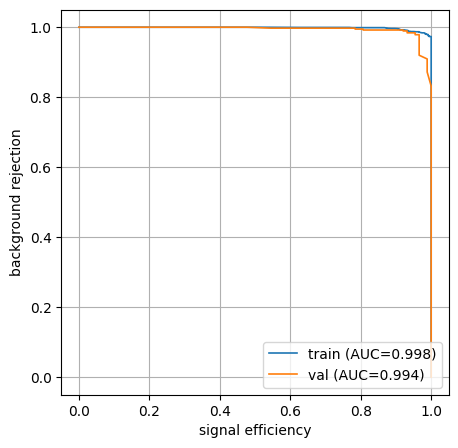

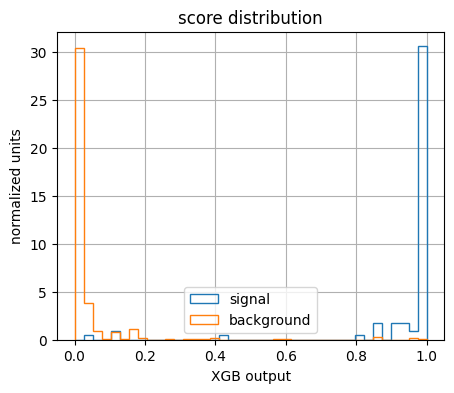

In [40]:
from sklearn.metrics import roc_curve, auc


train_pred_sklearn = model.predict_proba(X_train)[:, 1] # gets the predicted probabilities for the positive class
val_pred_sklearn = model.predict_proba(X_val)[:, 1]



fpr_train_sklearn, tpr_train_sklearn, _ = roc_curve(y_train, train_pred_sklearn)
fpr_val_sklearn, tpr_val_sklearn, _ = roc_curve(y_val, val_pred_sklearn)



train_auc_sklearn = auc(fpr_train_sklearn, tpr_train_sklearn)
val_auc_sklearn = auc(fpr_val_sklearn, tpr_val_sklearn)


print(f"train AUC (sklearn): {train_auc_sklearn:.3f}")
print(f"validation AUC (sklearn): {val_auc_sklearn:.3f}")




# roc curve using sklearn wrapper
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(tpr_train_sklearn, 1 - fpr_train_sklearn, lw=1.2, label=f"train (AUC={train_auc_sklearn:.3f})") # 1 - fpr to give background rejection
ax.plot(tpr_val_sklearn, 1 - fpr_val_sklearn, lw=1.2, label=f"val (AUC={val_auc_sklearn:.3f})")
ax.set_xlabel("signal efficiency")
ax.set_ylabel("background rejection")
ax.set_title = ("roc curve")
ax.grid(True)
ax.legend(loc="lower right")
plt.show()




# score distribution using sklearn
bins = np.linspace(0, 1, 40)
sig_scores_sk = val_pred_sklearn[y_val == 1]
bkg_scores_sk = val_pred_sklearn[y_val == 0]
fig, ax = plt.subplots(figsize=(5,4))
ax.hist(sig_scores_sk, bins = bins, histtype = "step", density = True, label = "signal")
ax.hist(bkg_scores_sk, bins = bins, histtype = "step", density = True, label = "background")
ax.set_xlabel("XGB output")
ax.set_ylabel("normalized units")
ax.set_title("score distribution")
ax.legend()
ax.grid(True)
plt.show()

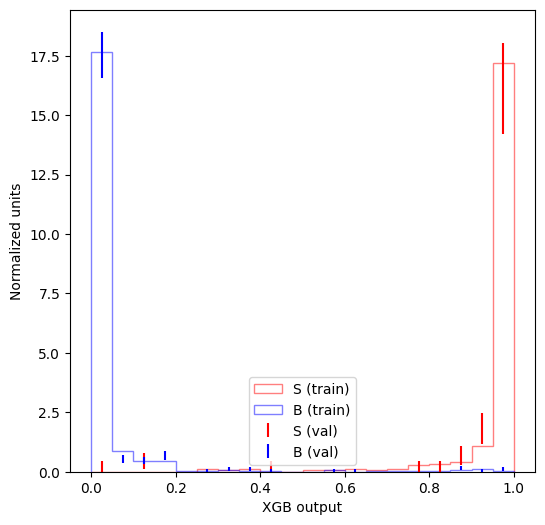

In [20]:
def compare_train_test(model, X_train, y_train, X_test, y_test, bins=20):
    decisions = []
    for X, y in ((X_train, y_train), (X_test, y_test)):
        scores = model.predict_proba(X)[:, 1]
        d1 = scores[y > 0.5].ravel()  # .ravel() to ensure 1D hist for use with plt.hist()
        d2 = scores[y < 0.5].ravel()
        decisions += [d1, d2]

    plt.subplots(figsize=(6, 6))
    plt.hist(decisions[0],
             color="r", alpha=0.5, range=(0, 1), bins=bins,
             histtype="step", density=1,
             label="S (train)")
    plt.hist(decisions[1],
             color="b", alpha=0.5, range=(0, 1), bins=bins,
             histtype="step", density=1,
             label="B (train)")

    hist, bins = np.histogram(decisions[2], bins=bins, range=(0, 1), density=1)
    scale = len(decisions[2]) / sum(hist)
    err = np.sqrt(hist * scale) / scale

    width = (bins[1] - bins[0])
    center = (bins[:-1] + bins[1:]) / 2
    plt.errorbar(center, hist, yerr=err, fmt="none", c="r", label="S (val)")

    hist, bins = np.histogram(decisions[3], bins=bins, range=(0, 1), density=1)
    scale = len(decisions[3]) / sum(hist)
    err = np.sqrt(hist * scale) / scale

    plt.errorbar(center, hist, yerr=err, fmt="none", c="b", label="B (val)")

    plt.xlabel("XGB output")
    plt.ylabel("Normalized units")
    plt.legend(loc="best")
    #plt.savefig("Xgboutput.png", bbox_inches="tight")

compare_train_test(model, X_train, y_train, X_val, y_val)

Text(0.5, 1.0, 'cover-based importance')

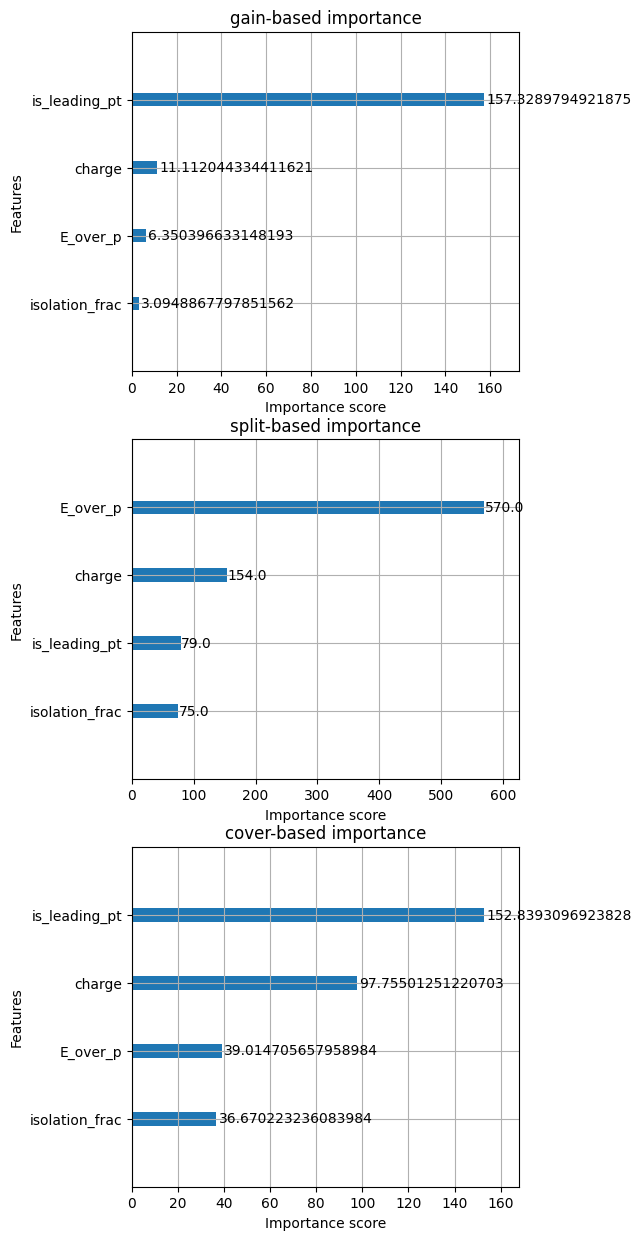

In [ ]:
# three different types of importance
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (5, 15))

xgb.plot_importance(model, ax = ax1, importance_type = "gain")
ax1.set_title("gain-based importance")

xgb.plot_importance(model, ax = ax2, importance_type = "weight")
ax2.set_title("split-based importance")

xgb.plot_importance(model, ax = ax3, importance_type = "cover")
ax3.set_title("cover-based importance")

In [94]:
print(event_info_val['Q2'].values.argmax())

2121


In [96]:
def efficiency_purity_vs_bjorken(val_pred, yval, event_info_val, threshold = 0.5):
    predicted_electrons = val_pred > threshold
    
    Q2_bins = np.logspace(0, 2, base=20)
    Q2_values = event_info_val['Q2'].values

    x_bins = np.logspace(-3, 0, base = 10)
    x_values = event_info_val['x'].values

    y_bins = np.logspace(-3, 0, base = 10)
    y_values = event_info_val['y'].values

    efficiencies_Q2 = []
    purities_Q2 = []
    bin_centers_Q2 = []

    efficiencies_x = []
    purities_x = []
    bin_centers_x = []

    efficiencies_y = []
    purities_y = []
    bin_centers_y = []

    true_electrons_per_bin_Q2 = []
    true_electrons_per_bin_x = []
    true_electrons_per_bin_y = []

    
    # begin with Q2
    for bin in range(len(Q2_bins) - 1):
        bin_bottom = Q2_bins[bin]
        bin_top = Q2_bins[bin + 1]
        bin_center = (bin_bottom + bin_top) / 2
        bin_centers_Q2.append(bin_center)

        in_bin = (Q2_values >= bin_bottom) & (Q2_values < bin_top)

        if np.sum(in_bin) == 0: # just incase there are no events in the bin
            efficiencies_Q2.append(0)
            purities_Q2.append(0)
            true_electrons_per_bin_Q2.append(0)
            continue

        y_true_bin = y_val[in_bin]
        y_pred_bin = predicted_electrons[in_bin]

        tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1)) # true positives
        fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1)) # false positives
        fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0)) # false negatives

        efficiency = tp / (tp + fn)
        purity = tp / (tp + fp)

        efficiencies_Q2.append(efficiency)
        purities_Q2.append(purity)
        true_electrons_per_bin_Q2.append(np.sum(y_true_bin == 1))
    
    # now x
    for bin in range(len(x_bins) - 1):
        bin_bottom = x_bins[bin]
        bin_top = x_bins[bin + 1]
        bin_center = (bin_bottom + bin_top) / 2
        bin_centers_x.append(bin_center)

        in_bin = (x_values >= bin_bottom) & (x_values < bin_top)

        if np.sum(in_bin) == 0: # just incase there are no events in the bin
            efficiencies_x.append(0)
            purities_x.append(0)
            true_electrons_per_bin_x.append(0)
            continue

        y_true_bin = y_val[in_bin]
        y_pred_bin = predicted_electrons[in_bin]

        tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1)) # true positives
        fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1)) # false positives
        fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0)) # false negatives

        efficiency = tp / (tp + fn)
        purity = tp / (tp + fp)

        efficiencies_x.append(efficiency)
        purities_x.append(purity)
        true_electrons_per_bin_x.append(np.sum(y_true_bin == 1))
    
    # now y
    for bin in range(len(y_bins) - 1):
        bin_bottom = y_bins[bin]
        bin_top = y_bins[bin + 1]
        bin_center = (bin_bottom + bin_top) / 2
        bin_centers_y.append(bin_center)

        in_bin = (y_values >= bin_bottom) & (y_values < bin_top)

        if np.sum(in_bin) == 0: # just incase there are no events in the bin
            efficiencies_y.append(0)
            purities_y.append(0)
            true_electrons_per_bin_y.append(0)
            continue

        y_true_bin = y_val[in_bin]
        y_pred_bin = predicted_electrons[in_bin]

        tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1)) # true positives
        fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1)) # false positives
        fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0)) # false negatives

        efficiency = tp / (tp + fn)
        purity = tp / (tp + fp)

        efficiencies_y.append(efficiency)
        purities_y.append(purity)
        true_electrons_per_bin_y.append(np.sum(y_true_bin == 1))

    return (bin_centers_Q2, efficiencies_Q2, purities_Q2,
            bin_centers_x, efficiencies_x, purities_x,
            bin_centers_y, efficiencies_y, purities_y, true_electrons_per_bin_Q2, true_electrons_per_bin_x, true_electrons_per_bin_y)

In [97]:
evaluation_results = efficiency_purity_vs_bjorken(val_pred, y_val, event_info_val, threshold = 0.5)

In [98]:
bin_centers_Q2, efficiencies_Q2, purities_Q2, bin_centers_x, efficiencies_x, purities_x, bin_centers_y, efficiencies_y, purities_y, true_electrons_per_bin_Q2, true_electrons_per_bin_x, true_electrons_per_bin_y = evaluation_results

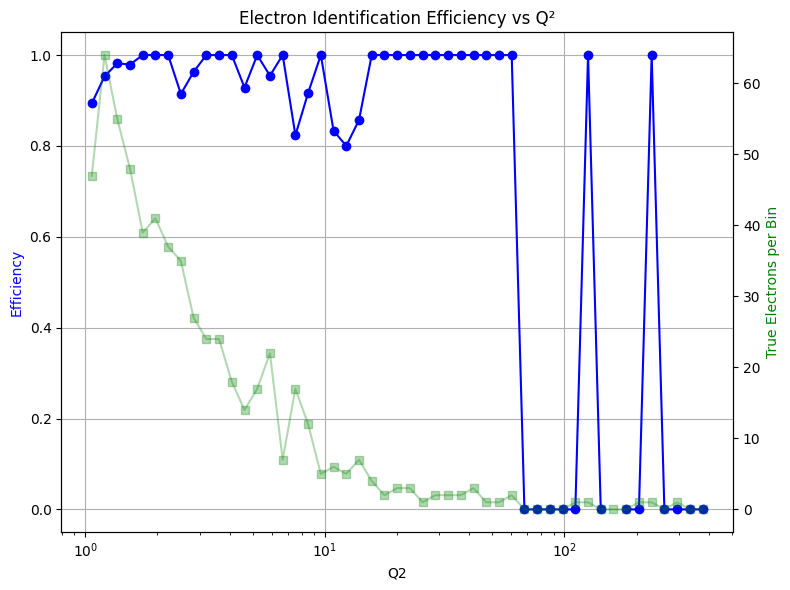

In [99]:
# Q2 efficiency plotting

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_Q2, efficiencies_Q2, marker='o', color='b', label='Efficiency')
ax1.set_xscale('log')
ax1.set_xlabel('Q2')
ax1.set_ylabel('Efficiency', color='b')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_Q2, true_electrons_per_bin_Q2, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')
ax2.set_ylabel('True Electrons per Bin', color='g')

plt.title('Electron Identification Efficiency vs Q²')
fig.tight_layout()
plt.show()

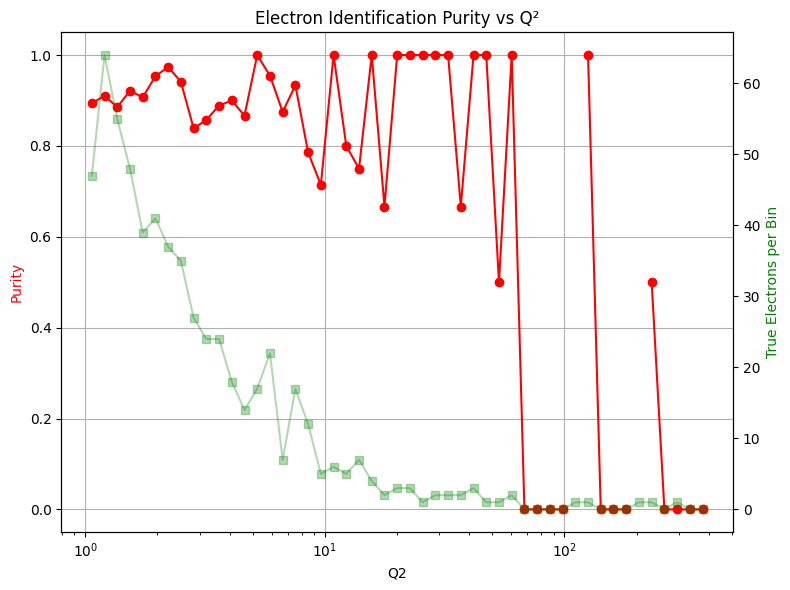

In [100]:
# Q2 purity plotting

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_Q2, purities_Q2, marker='o', color='r', label='Purity')
ax1.set_xscale('log')
ax1.set_xlabel('Q2')
ax1.set_ylabel('Purity', color='r')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_Q2, true_electrons_per_bin_Q2, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')
ax2.set_ylabel('True Electrons per Bin', color='g')

plt.title('Electron Identification Purity vs Q²')
fig.tight_layout()
plt.show()

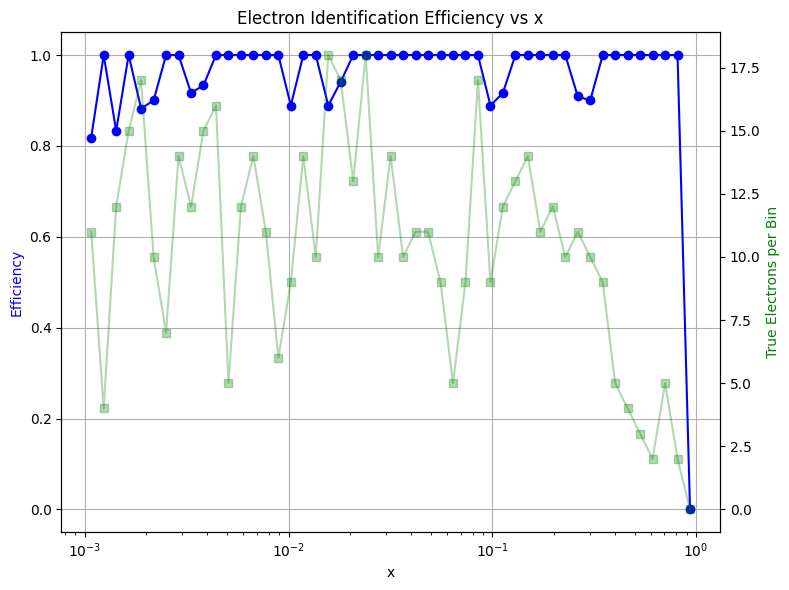

In [101]:
# x efficiency plotting

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_x, efficiencies_x, marker='o', color='b', label='Efficiency')
ax1.set_xscale('log')
ax1.set_xlabel('x')
ax1.set_ylabel('Efficiency', color='b')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_x, true_electrons_per_bin_x, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')

ax2.set_ylabel('True Electrons per Bin', color='g')
plt.title('Electron Identification Efficiency vs x')
fig.tight_layout()
plt.show()

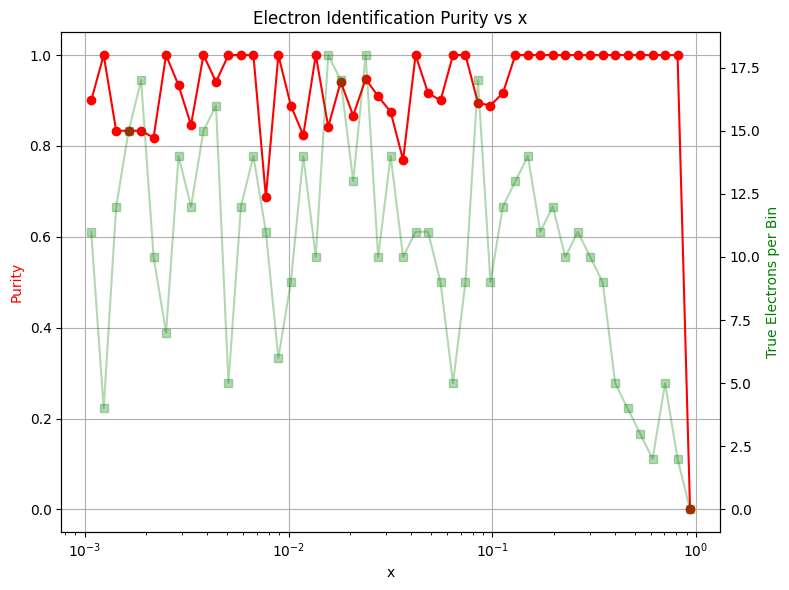

In [102]:
# x purity plotting

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_x, purities_x, marker='o', color='r', label='Purity')
ax1.set_xscale('log')
ax1.set_xlabel('x')
ax1.set_ylabel('Purity', color='r')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_x, true_electrons_per_bin_x, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')
ax2.set_ylabel('True Electrons per Bin', color='g')
plt.title('Electron Identification Purity vs x')
fig.tight_layout()
plt.show()

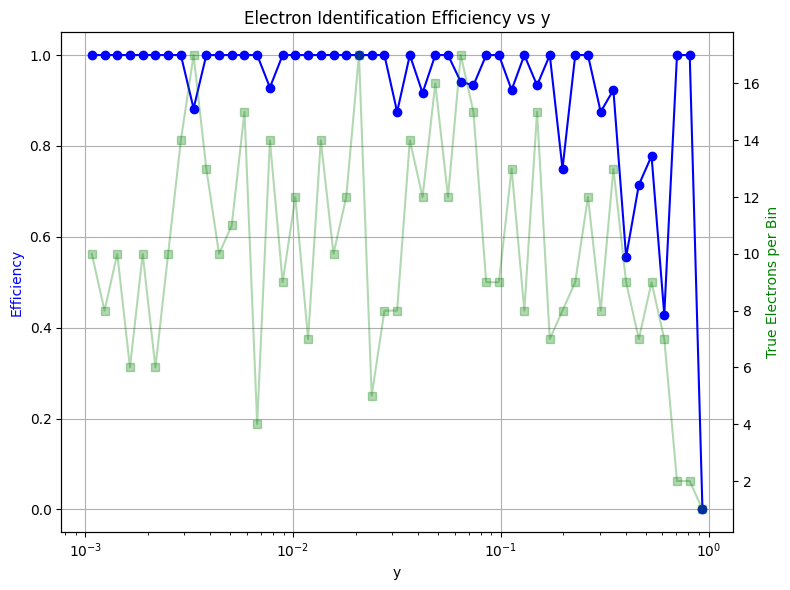

In [103]:
# y efficiency plotting
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_y, efficiencies_y, marker='o', color='b', label='Efficiency')
ax1.set_xscale('log')
ax1.set_xlabel('y')
ax1.set_ylabel('Efficiency', color='b')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_y, true_electrons_per_bin_y, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')

ax2.set_ylabel('True Electrons per Bin', color='g')
plt.title('Electron Identification Efficiency vs y')
fig.tight_layout()
plt.show()

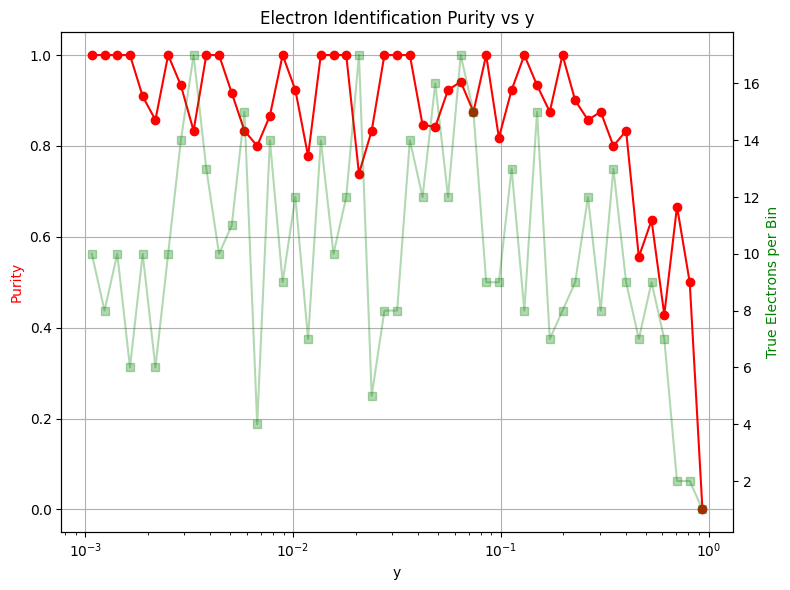

In [104]:
# y purity plotting
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_y, purities_y, marker='o', color='r', label='Purity')
ax1.set_xscale('log')
ax1.set_xlabel('y')
ax1.set_ylabel('Purity', color='r')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_y, true_electrons_per_bin_y, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')

ax2.set_ylabel('True Electrons per Bin', color='g')
plt.title('Electron Identification Purity vs y')
fig.tight_layout()
plt.show()

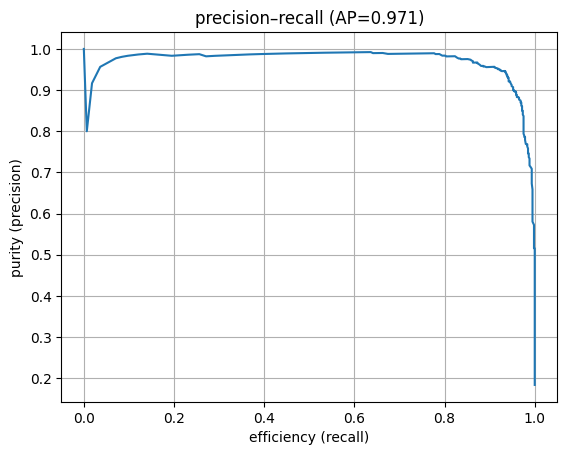

In [105]:
# precision-recall curve -> same as purity-efficiency curve but using a given function from sklearn
from sklearn.metrics import precision_recall_curve, average_precision_score 

precision, recall, thresholds = precision_recall_curve(y_val, val_pred)
ap = average_precision_score(y_val, val_pred)

plt.plot(recall, precision)
plt.xlabel('efficiency (recall)')
plt.ylabel('purity (precision)')
plt.title(f'precision–recall (AP={ap:.3f})')
plt.grid(True)
plt.show()